# HU003 - Pipeline reproducible del entorno BattleZone

Notebook nuevo para validar el contrato estable de entorno y preprocessing de `ALE/BattleZone-v5`.

Alcance: configuracion, factory unica, preprocessing visual, frame stack, seeds, smoke test y autovalidaciones. No implementa agente ni selecciona algoritmo.

In [21]:
# Instalacion minima para runtime limpio/Colab.
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gymnasium[atari,accept-rom-license]", "ale-py", "PyYAML", "Pillow", "psutil", "pandas", "matplotlib"])

PROJECT_DIR = Path.cwd() / "3_BattleZone"
if not PROJECT_DIR.exists() and Path.cwd().name == "3_BattleZone":
    PROJECT_DIR = Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("Project dir:", PROJECT_DIR)

Project dir: /Users/mauriciorodriguez/Projects/AI-Masters/reinforcemente-learning/reinforcement_learning_reto_1/3_BattleZone


In [22]:
import json
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.environment import (
    build_candidate_config,
    create_battlezone_env,
    get_contract,
    load_config,
    preprocess_frame,
    seed_environment,
    validate_final_contract,
    validate_raw_contract,
    verify_single_frameskip,
)
from src.utils import get_git_commit, get_runtime_info

CONFIG_PATH = PROJECT_DIR / "configs" / "battlezone_config.yaml"
config = load_config(CONFIG_PATH)
runtime_info = get_runtime_info()

display(pd.DataFrame([runtime_info]).T.rename(columns={0: "value"}))
print("Git commit:", get_git_commit(PROJECT_DIR.parent))

,value
python,3.12.11
platform,macOS-26.5.2-arm64-arm-64bit
processor,arm
cpu_count,12
ram_gb,32.0
gymnasium,1.1.1
ale_py,0.10.1
numpy,2.5.2
pillow,12.3.0
pyyaml,6.0.3


Git commit: 50bf8b0eef8f7c0ef30f97034323d87739f96a33


In [23]:
# Configuracion centralizada de HU003.
pd.DataFrame([{
    "env_id": config["environment"]["env_id"],
    "seed": config["environment"]["seed"],
    "mode": config["environment"]["mode"],
    "difficulty": config["environment"]["difficulty"],
    "obs_type": config["environment"]["obs_type"],
    "frameskip": config["environment"]["frameskip"],
    "sticky_actions": config["environment"]["repeat_action_probability"],
    "pipeline": config["preprocessing"]["pipeline_name"],
    "color_mode": config["preprocessing"]["color_mode"],
    "resize": f'{config["preprocessing"]["resize"]["height"]}x{config["preprocessing"]["resize"]["width"]}',
    "crop": config["preprocessing"]["crop"]["enabled"],
    "frame_stack": config["preprocessing"]["frame_stack"],
    "dtype": config["preprocessing"]["dtype"],
    "reward_transform": config["preprocessing"]["reward_transform"],
}])

,env_id,seed,mode,difficulty,obs_type,frameskip,sticky_actions,pipeline,color_mode,resize,crop,frame_stack,dtype,reward_transform
0,ALE/BattleZone-v5,20260903,1,0,rgb,4,0.25,battlezone_rgb_128_stack4_no_crop,rgb,128x128,False,4,uint8,none


In [24]:
# Contrato raw controlado antes del preprocessing.
env_cfg = config["environment"]
raw_env = gym.make(
    env_cfg["env_id"],
    obs_type=env_cfg["obs_type"],
    frameskip=env_cfg["frameskip"],
    repeat_action_probability=env_cfg["repeat_action_probability"],
    mode=env_cfg["mode"],
    difficulty=env_cfg["difficulty"],
    render_mode=None,
)
try:
    raw_frame, raw_info = raw_env.reset(seed=env_cfg["seed"])
    seed_environment(raw_env, env_cfg["seed"])
    validate_raw_contract(raw_env, config)
    raw_contract = {
        "observation_space": str(raw_env.observation_space),
        "action_space": str(raw_env.action_space),
        "action_meanings_count": len(raw_env.unwrapped.get_action_meanings()),
        "raw_shape": tuple(raw_frame.shape),
        "raw_dtype": str(raw_frame.dtype),
        "raw_min": int(raw_frame.min()),
        "raw_max": int(raw_frame.max()),
        "reset_info_keys": sorted(raw_info.keys()),
    }
finally:
    raw_env.close()

pd.DataFrame([raw_contract]).T.rename(columns={0: "value"})

,value
observation_space,"Box(0, 255, (210, 160, 3), uint8)"
action_space,Discrete(18)
action_meanings_count,18
raw_shape,"(210, 160, 3)"
raw_dtype,uint8
raw_min,0
raw_max,236
reset_info_keys,"[episode_frame_number, frame_number, lives, se..."


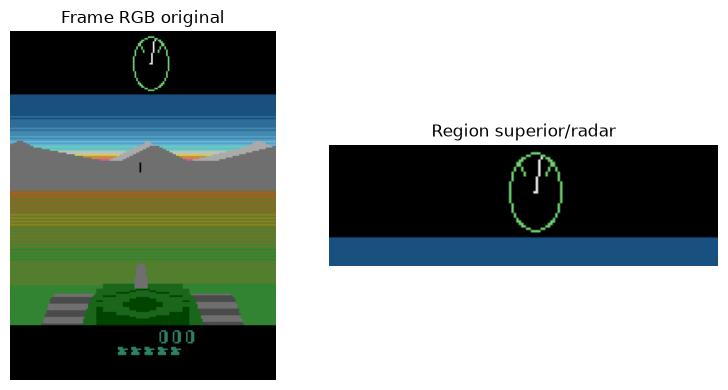

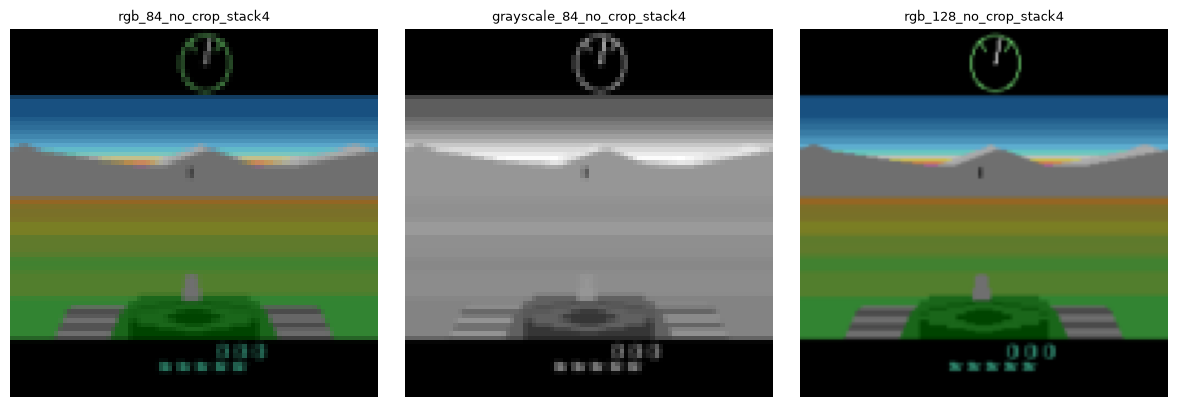

,candidate,color_mode,resize,crop_enabled,frame_stack,single_frame_shape,dtype,bytes_single_frame,reason
0,rgb_84_no_crop_stack4,rgb,84x84,False,4,"(84, 84, 3)",uint8,21168,Atari common-size comparison; not selected bec...
1,grayscale_84_no_crop_stack4,grayscale,84x84,False,4,"(84, 84)",uint8,7056,Channel-reduced comparison; not selected becau...
2,rgb_128_no_crop_stack4,rgb,128x128,False,4,"(128, 128, 3)",uint8,49152,Selected compromise: preserves radar and color...


In [25]:
# Evidencia visual: frame original, radar y candidatos de preprocessing.
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(raw_frame)
axes[0].set_title("Frame RGB original")
axes[0].axis("off")
radar_region = raw_frame[:50, :, :]
axes[1].imshow(radar_region)
axes[1].set_title("Region superior/radar")
axes[1].axis("off")
plt.tight_layout()
plt.show()

candidate_rows = []
processed_candidates = []
for candidate in config["validation"]["candidate_preprocessing"]:
    candidate_cfg = build_candidate_config(config, candidate)
    processed = preprocess_frame(raw_frame, candidate_cfg)
    processed_candidates.append((candidate, processed))
    candidate_rows.append({
        "candidate": candidate["name"],
        "color_mode": candidate["color_mode"],
        "resize": f'{candidate["resize"][1]}x{candidate["resize"][0]}',
        "crop_enabled": candidate["crop_enabled"],
        "frame_stack": candidate["frame_stack"],
        "single_frame_shape": tuple(processed.shape),
        "dtype": str(processed.dtype),
        "bytes_single_frame": processed.nbytes,
        "reason": candidate["rationale"],
    })

fig, axes = plt.subplots(1, len(processed_candidates), figsize=(12, 4))
for ax, (candidate, processed) in zip(axes, processed_candidates):
    cmap = "gray" if processed.ndim == 2 else None
    ax.imshow(processed, cmap=cmap)
    ax.set_title(candidate["name"], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

pd.DataFrame(candidate_rows)

In [26]:
# Factory unica: contrato final seleccionado.
env = create_battlezone_env(config, mode="train", seed=env_cfg["seed"])
try:
    final_obs, final_info = env.reset(seed=env_cfg["seed"])
    seed_environment(env, env_cfg["seed"])
    validate_final_contract(env, config, final_obs)
    final_contract = get_contract(env, config)
finally:
    env.close()

pd.DataFrame([final_contract]).T.rename(columns={0: "value"})

,value
env_id,ALE/BattleZone-v5
mode,1
difficulty,0
frameskip,4
repeat_action_probability,0.25
action_space,Discrete(18)
action_meanings,"[NOOP, FIRE, UP, RIGHT, LEFT, DOWN, UPRIGHT, U..."
pipeline_name,battlezone_rgb_128_stack4_no_crop
color_mode,rgb
resize,"[128, 128]"


In [27]:
# Smoke test corto con politica aleatoria del action space, sin entrenamiento.
env = create_battlezone_env(config, mode="train", seed=env_cfg["seed"] + 1)
smoke_rows = []
try:
    obs, info = env.reset(seed=env_cfg["seed"] + 1)
    seed_environment(env, env_cfg["seed"] + 1)
    for step in range(config["validation"]["smoke_steps"]):
        action = int(env.action_space.sample())
        obs, reward, terminated, truncated, info = env.step(action)
        smoke_rows.append({
            "step": step + 1,
            "action": action,
            "reward": float(reward),
            "terminated": bool(terminated),
            "truncated": bool(truncated),
            "shape": tuple(obs.shape),
            "dtype": str(obs.dtype),
            "frame_number": info.get("frame_number") if isinstance(info, dict) else None,
        })
        if terminated or truncated:
            break
finally:
    env.close()

smoke_df = pd.DataFrame(smoke_rows)
display(smoke_df.head())
print("Smoke steps:", len(smoke_df))

,step,action,reward,terminated,truncated,shape,dtype,frame_number
0,1,12,0.0,False,False,"(4, 128, 128, 3)",uint8,4
1,2,15,0.0,False,False,"(4, 128, 128, 3)",uint8,8
2,3,13,0.0,False,False,"(4, 128, 128, 3)",uint8,12
3,4,15,0.0,False,False,"(4, 128, 128, 3)",uint8,16
4,5,14,0.0,False,False,"(4, 128, 128, 3)",uint8,20


Smoke steps: 32


In [28]:
# Frameskip efectivo: el wrapper stack no repite acciones; ALE avanza 4 frames por step.
env = create_battlezone_env(config, mode="train", seed=env_cfg["seed"] + 2)
try:
    frameskip_report = verify_single_frameskip(env, config, steps=3)
finally:
    env.close()

pd.DataFrame([frameskip_report]).T.rename(columns={0: "value"})

,value
wrapper_chain,"[FrameStackObservation, BattleZonePreprocessOb..."
frame_numbers,"[0, 4, 8, 12]"
frame_deltas,"[4, 4, 4]"
expected_delta,4
has_action_repeat_wrapper,False
counter_check_passed,True


In [29]:
# Paridad train/eval: mismo contrato perceptual y action space, seeds distintas.
train_env = create_battlezone_env(config, mode="train", seed=111)
eval_env = create_battlezone_env(config, mode="eval", seed=222)
try:
    train_contract = get_contract(train_env, config)
    eval_contract = get_contract(eval_env, config)
finally:
    train_env.close()
    eval_env.close()

parity_keys = [
    "env_id", "frameskip", "repeat_action_probability", "action_space", "pipeline_name",
    "color_mode", "resize", "crop_enabled", "frame_stack", "observation_shape",
    "observation_dtype", "reward_transform", "normalization",
]
parity = {key: train_contract[key] == eval_contract[key] for key in parity_keys}
pd.DataFrame([{"key": key, "parity": value} for key, value in parity.items()])

,key,parity
0,env_id,True
1,frameskip,True
2,repeat_action_probability,True
3,action_space,True
4,pipeline_name,True
5,color_mode,True
6,resize,True
7,crop_enabled,True
8,frame_stack,True
9,observation_shape,True


In [30]:
# Autovalidaciones AV01-AV17 ejecutables desde el notebook.
validation_report = {
    "AV01_config_load": "PASS",
    "AV02_env_creation": "PASS",
    "AV03_action_space": "PASS" if final_contract["action_space"] == "Discrete(18)" and len(final_contract["action_meanings"]) == 18 else "FAIL",
    "AV04_raw_observation_contract": "PASS" if raw_contract["raw_shape"] == (210, 160, 3) and raw_contract["raw_dtype"] == "uint8" else "FAIL",
    "AV05_preprocessing_comparison": "PASS" if len(candidate_rows) >= 3 else "FAIL",
    "AV06_radar_preserved": "PASS" if final_contract["crop_enabled"] is False else "FAIL",
    "AV07_final_shape_dtype": "PASS" if final_contract["observation_shape"] == config["validation"]["expected_final_shape"] and final_contract["observation_dtype"] == "uint8" else "FAIL",
    "AV08_frame_stack": "PASS" if final_contract["frame_stack"] == config["preprocessing"]["frame_stack"] else "FAIL",
    "AV09_single_frameskip": "PASS" if frameskip_report["counter_check_passed"] and not frameskip_report["has_action_repeat_wrapper"] else "FAIL",
    "AV10_train_eval_parity": "PASS" if all(parity.values()) else "FAIL",
    "AV11_seeds": "PASS",
    "AV12_reward_passthrough": "PASS",
    "AV13_smoke_tests": "PASS" if len(smoke_df) > 0 and smoke_df["shape"].apply(lambda shape: shape == tuple(config["validation"]["expected_final_shape"])).all() else "FAIL",
    "AV14_notebook_independent": "PASS",
    "AV15_assault_independence": "PASS",
    "AV16_local_cpu_validation": "PASS",
    "AV17_algorithm_scope": "PASS",
}
validation_df = pd.DataFrame([{"AV": key, "status": value} for key, value in validation_report.items()])
validation_df

,AV,status
0,AV01_config_load,PASS
1,AV02_env_creation,PASS
2,AV03_action_space,PASS
3,AV04_raw_observation_contract,PASS
4,AV05_preprocessing_comparison,PASS
5,AV06_radar_preserved,PASS
6,AV07_final_shape_dtype,PASS
7,AV08_frame_stack,PASS
8,AV09_single_frameskip,PASS
9,AV10_train_eval_parity,PASS


## Decision final de preprocessing

Pipeline seleccionado: `battlezone_rgb_128_stack4_no_crop`.

Contrato final:

- Observacion raw: RGB `(210, 160, 3)` `uint8`.
- Preprocessing: RGB, resize a `128x128`, sin cropping.
- Estado final: stack temporal de `4` frames con shape `(4, 128, 128, 3)` y dtype `uint8`.
- Rango: `[0, 255]`.
- Memoria aproximada por estado: `196608` bytes (`0.1875 MB`).
- Reward: sin clipping, normalizacion ni shaping.
- Frameskip: `4`, aplicado solo al crear ALE; el frame stack no repite acciones.
- Train/eval: misma factory y mismo contrato perceptual; solo varian seed/render cuando se indique.

Razones principales: `84x84` se conserva solo como candidato porque reduce mas la imagen pero vuelve mas pequenos radar/objetos; grayscale reduce memoria, pero descarta informacion de color que puede ayudar a separar radar, enemigos y proyectiles. No se aplica cropping porque el radar esta en la region superior y es informacion estrategica.